In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/datathon-2026-round-1/products.csv
/kaggle/input/competitions/datathon-2026-round-1/sample_submission.csv
/kaggle/input/competitions/datathon-2026-round-1/promotions.csv
/kaggle/input/competitions/datathon-2026-round-1/shipments.csv
/kaggle/input/competitions/datathon-2026-round-1/order_items.csv
/kaggle/input/competitions/datathon-2026-round-1/reviews.csv
/kaggle/input/competitions/datathon-2026-round-1/inventory.csv
/kaggle/input/competitions/datathon-2026-round-1/returns.csv
/kaggle/input/competitions/datathon-2026-round-1/sales.csv
/kaggle/input/competitions/datathon-2026-round-1/orders.csv
/kaggle/input/competitions/datathon-2026-round-1/geography.csv
/kaggle/input/competitions/datathon-2026-round-1/customers.csv
/kaggle/input/competitions/datathon-2026-round-1/baseline.ipynb
/kaggle/input/competitions/datathon-2026-round-1/payments.csv
/kaggle/input/competitions/datathon-2026-round-1/web_traffic.csv


In [2]:
import pandas as pd
import numpy as np
import os
import gc
import warnings
warnings.filterwarnings('ignore')

# Định nghĩa đường dẫn
BASE_PATH = '/kaggle/input/competitions/datathon-2026-round-1/'

# Định nghĩa hàm load để tái sử dụng và kiểm soát lỗi
def load_and_prep_data():
    print("🚀 Đang khởi tạo và load dữ liệu từ:", BASE_PATH)
    
    # Parse_dates giúp chuyển các cột thời gian từ string sang datetime ngay lập tức
    products    = pd.read_csv(BASE_PATH + 'products.csv')
    customers   = pd.read_csv(BASE_PATH + 'customers.csv',   parse_dates=['signup_date'])
    promotions  = pd.read_csv(BASE_PATH + 'promotions.csv',  parse_dates=['start_date', 'end_date'])
    geography   = pd.read_csv(BASE_PATH + 'geography.csv')
    orders      = pd.read_csv(BASE_PATH + 'orders.csv',      parse_dates=['order_date'])
    order_items = pd.read_csv(BASE_PATH + 'order_items.csv')
    payments    = pd.read_csv(BASE_PATH + 'payments.csv')
    shipments   = pd.read_csv(BASE_PATH + 'shipments.csv',   parse_dates=['ship_date', 'delivery_date'])
    returns     = pd.read_csv(BASE_PATH + 'returns.csv',     parse_dates=['return_date'])
    reviews     = pd.read_csv(BASE_PATH + 'reviews.csv',     parse_dates=['review_date'])
    sales       = pd.read_csv(BASE_PATH + 'sales.csv',       parse_dates=['Date'])
    inventory   = pd.read_csv(BASE_PATH + 'inventory.csv',   parse_dates=['snapshot_date'])
    web_traffic = pd.read_csv(BASE_PATH + 'web_traffic.csv', parse_dates=['date'])

    # 2. Xử lý các giá trị Null cơ bản
    # Thay thế age_group null bằng 'Unknown' để không bị mất dữ liệu khi group
    customers['age_group'] = customers['age_group'].fillna('Unknown')

    # 3. Tạo các cột thời gian phái sinh (Feature Engineering)
    orders['month'] = orders['order_date'].dt.to_period('M').astype(str)
    orders['year'] = orders['order_date'].dt.year

    # 4. Thực hiện các bước JOIN chính theo Cardinality
    # Join 1:1:1 (Orders - Payments - Customers)
    df_master = orders.merge(payments, on='order_id', how='left')
    df_master = df_master.merge(customers, on='customer_id', how='left')

    # Join Logistics (Shipments - Reviews - Geo)
    # Lưu ý: Zip trong orders thường dùng để giao hàng
    df_logistics = shipments.merge(reviews, on='order_id', how='left')
    df_logistics = df_logistics.merge(orders[['order_id', 'zip']], on='order_id', how='left')
    df_logistics = df_logistics.merge(geography, on='zip', how='left')

    # Join Inventory & Products
    df_inventory_master = inventory.merge(products, on='product_id', how='left')

    # Ops & Product joins (Phần 2)
    orders_geo   = orders.merge(geography[['zip', 'region']], on='zip', how='left')
    orders_cust  = orders.merge(customers[['customer_id', 'age_group']], on='customer_id', how='left')
    orders_sorted = orders.sort_values(['customer_id', 'order_date']).copy()

    oi_prod  = order_items.merge(
        products[['product_id', 'size', 'category', 'segment']], on='product_id', how='left'
    )
    ret_prod = returns.merge(
        products[['product_id', 'size', 'category', 'segment']], on='product_id', how='left'
    )
    returns_prod = returns.merge(
        products[['product_id', 'category']], on='product_id', how='left'
    )

    return {
        # Raw tables
        'products': products,       'customers': customers,
        'promotions': promotions,   'geography': geography,
        'orders': orders,           'order_items': order_items,
        'payments': payments,       'shipments': shipments,
        'returns': returns,         'reviews': reviews,
        'sales': sales,             'inventory': inventory,
        'web_traffic': web_traffic,
        # Joined / derived
        'df_master': df_master,
        'df_logistics': df_logistics,
        'df_inventory_master': df_inventory_master,
        'orders_geo': orders_geo,
        'orders_cust': orders_cust,
        'orders_sorted': orders_sorted,
        'oi_prod': oi_prod,
        'ret_prod': ret_prod,
        'returns_prod': returns_prod,
    }

# Gọi hàm để lấy dữ liệu
data = load_and_prep_data()

# Giải nén các dataframe để dùng trực tiếp như các phần code trước
products      = data['products']
customers     = data['customers']
promotions    = data['promotions']
geography     = data['geography']
orders        = data['orders']
order_items   = data['order_items']
payments      = data['payments']
shipments     = data['shipments']
returns       = data['returns']
reviews       = data['reviews']
sales         = data['sales']
inventory     = data['inventory']
web_traffic   = data['web_traffic']

df_master           = data['df_master']
df_logistics        = data['df_logistics']
df_inventory_master = data['df_inventory_master']
orders_geo          = data['orders_geo']
orders_cust         = data['orders_cust']
orders_sorted       = data['orders_sorted']
oi_prod             = data['oi_prod']
ret_prod            = data['ret_prod']
returns_prod        = data['returns_prod']

🚀 Đang khởi tạo và load dữ liệu từ: /kaggle/input/competitions/datathon-2026-round-1/


In [3]:
# Display summary statistics for the orders dataframe
display(orders.describe(include='all'))

# Display basic info including non-null counts and data types
print('\nDataFrame Info:')
display(orders.info())

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,month,year
count,646945.000000,646945,646945.000000,646945.000000,646945,646945,646945,646945,646945,646945.000000
unique,NaN,NaN,NaN,NaN,6,5,3,6,126,NaN
top,NaN,NaN,NaN,NaN,delivered,credit_card,mobile,organic_search,2018-06,NaN
freq,NaN,NaN,NaN,NaN,516716,356352,291482,181495,10851,NaN
mean,417189.470332,2016-11-28 05:46:39.463323904,84906.203535,55410.740423,NaN,NaN,NaN,NaN,NaN,2016.410148
min,1.000000,2012-07-04 00:00:00,1.000000,1001.000000,NaN,NaN,NaN,NaN,NaN,2012.000000
25%,208728.000000,2014-08-05 00:00:00,41336.000000,30904.000000,NaN,NaN,NaN,NaN,NaN,2014.000000
50%,417211.000000,2016-07-25 00:00:00,87279.000000,54129.000000,NaN,NaN,NaN,NaN,NaN,2016.000000
75%,625628.000000,2018-08-27 00:00:00,133282.000000,83301.000000,NaN,NaN,NaN,NaN,NaN,2018.000000
max,834397.000000,2022-12-31 00:00:00,157563.000000,99950.000000,NaN,NaN,NaN,NaN,NaN,2022.000000



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        646945 non-null  int64         
 1   order_date      646945 non-null  datetime64[ns]
 2   customer_id     646945 non-null  int64         
 3   zip             646945 non-null  int64         
 4   order_status    646945 non-null  object        
 5   payment_method  646945 non-null  object        
 6   device_type     646945 non-null  object        
 7   order_source    646945 non-null  object        
 8   month           646945 non-null  object        
 9   year            646945 non-null  int32         
dtypes: datetime64[ns](1), int32(1), int64(3), object(5)
memory usage: 46.9+ MB


None

**Setup**

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
    'figure.facecolor' : 'white',
    'savefig.dpi'      : 150,
    'savefig.bbox'     : 'tight',
    'savefig.facecolor': 'white',
})

**Return Rate theo Size × Category**

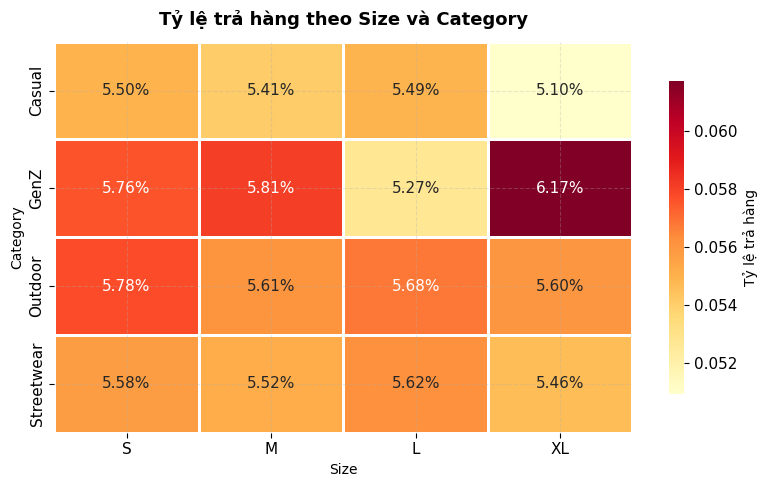

=== RETURN RATE — KEY FINDINGS ===
Tổ hợp có tỷ lệ trả hàng cao nhất : GenZ × XL = 6.175%
Tỷ lệ trả hàng trung bình         : 5.59%
Tỷ lệ trả hàng theo danh mục (tăng dần):
category
Casual        5.39%
Streetwear    5.54%
Outdoor       5.66%
GenZ          5.72%


In [5]:
# ── Chuẩn bị data ────────────────────────────────────────────
oi_size_cat = (
    oi_prod.groupby(['size', 'category'])['order_id']
           .count().reset_index()
           .rename(columns={'order_id': 'oi_count'})
)
ret_size_cat = (
    ret_prod.groupby(['size', 'category'])['return_id']
            .count().reset_index()
            .rename(columns={'return_id': 'ret_count'})
)
rate_df = oi_size_cat.merge(ret_size_cat, on=['size', 'category'], how='left')
rate_df['ret_count']   = rate_df['ret_count'].fillna(0)
rate_df['return_rate'] = rate_df['ret_count'] / rate_df['oi_count']

pivot   = rate_df.pivot(index='category', columns='size', values='return_rate')
pivot   = pivot[['S', 'M', 'L', 'XL']]

# ── Key numbers ──────────────────────────────────────────────
worst     = rate_df.sort_values('return_rate', ascending=False).iloc[0]
avg_rate  = rate_df['return_rate'].mean()
cat_rate  = (
    rate_df.groupby('category')
           .apply(lambda x: x['ret_count'].sum() / x['oi_count'].sum())
           .sort_values()
)

# ── Tỷ lệ trả hàng theo Size và Category ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot, ax=ax,
    annot=True, fmt='.2%',
    cmap='YlOrRd',
    linewidths=0.8, linecolor='white',
    cbar_kws={'label': 'Tỷ lệ trả hàng', 'shrink': 0.8}
)
ax.set_title('Tỷ lệ trả hàng theo Size và Category', pad=12)
ax.set_xlabel('Size'); ax.set_ylabel('Category')
plt.tight_layout()
plt.savefig(
    '/kaggle/working/TBT_Fig3_ReturnRate_SizeCategory.png',  
    dpi=150,                       
    bbox_inches='tight',         
    facecolor='white',            
    format='png'                  
)
plt.show()

# ── Key findings ───────────────────────────────────────────
print("=== RETURN RATE — KEY FINDINGS ===")
print(f"Tổ hợp có tỷ lệ trả hàng cao nhất : {worst['category']} × {worst['size']} = {worst['return_rate']:.3%}")
print(f"Tỷ lệ trả hàng trung bình         : {avg_rate:.2%}")
print(f"Tỷ lệ trả hàng theo danh mục (tăng dần):")
print(cat_rate.apply(lambda x: f"{x:.2%}").to_string())

**Stockout vs Revenue Lost**

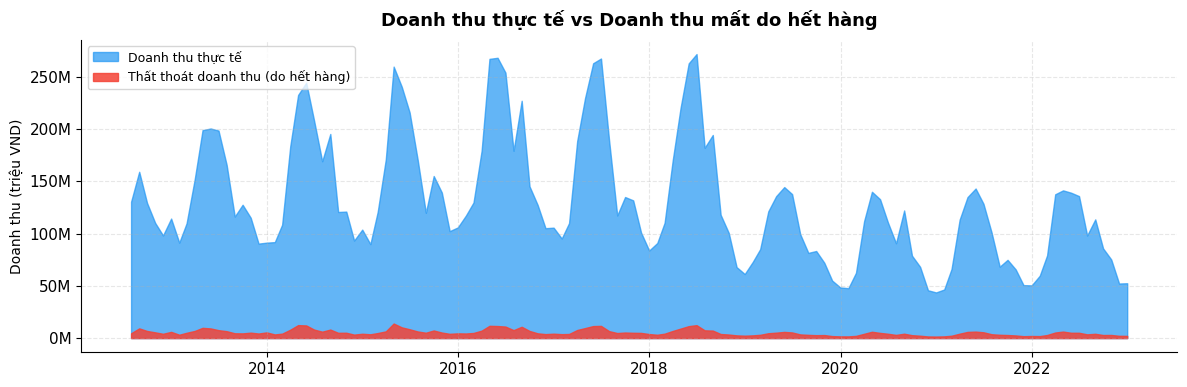

=== STOCKOUT — KEY FINDINGS ===
Tổng thiệt hại doanh thu ước tính       : 0.677 tỷ VND
Tỷ lệ thất thoát trên doanh thu thực tế : 4.12% revenue
Fill rate trung bình toàn kỳ            : 96.140%
Phần trăm sản phẩm hết hàng trung bình  : 67.311%
Tháng có thất thoát cao nhất            : 04/2015
Thất thoát doanh thu trong tháng tệ nhất: -13.922M VND


In [6]:
# ── Chuẩn bị data ────────────────────────────────────────────
inv_monthly = inventory.groupby('snapshot_date').agg(
    total_stockout_days=('stockout_days', 'sum'),
    avg_fill_rate=('fill_rate', 'mean'),
    pct_stockout=('stockout_flag', 'mean')
).reset_index()

sales['month']      = sales['Date'].dt.to_period('M')
sales_monthly       = sales.groupby('month')['Revenue'].sum().reset_index()
sales_monthly['snapshot_date'] = sales_monthly['month'].dt.to_timestamp('M')

inv_m = inv_monthly.merge(
    sales_monthly[['snapshot_date', 'Revenue']], on='snapshot_date', how='inner'
)
inv_m['revenue_lost_est'] = (
    inv_m['Revenue'] * (1 - inv_m['avg_fill_rate']) / inv_m['avg_fill_rate']
)

# ── Key numbers ──────────────────────────────────────────────
total_lost       = inv_m['revenue_lost_est'].sum()
lost_ratio       = total_lost / inv_m['Revenue'].sum()
fill_rate_avg    = inv_m['avg_fill_rate'].mean()
pct_stockout_avg = inv_m['pct_stockout'].mean()
worst_month      = inv_m.loc[inv_m['revenue_lost_est'].idxmax(), 'snapshot_date']
worst_loss       = inv_m['revenue_lost_est'].max()

# ── Chart: Area chart ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(inv_m['snapshot_date'], inv_m['Revenue'] / 1e6,
                alpha=0.7, color='#2196F3', label='Doanh thu thực tế')
ax.fill_between(inv_m['snapshot_date'], inv_m['revenue_lost_est'] / 1e6,
                alpha=0.85, color='#f44336', label='Thất thoát doanh thu (do hết hàng)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax.set_ylabel('Doanh thu (triệu VND)')
ax.legend(fontsize=9, loc='upper left')
ax.set_title('Doanh thu thực tế vs Doanh thu mất do hết hàng', pad=10)
plt.tight_layout()
plt.savefig(
    '/kaggle/working/TBT_Fig4_Stockout_RevenueLost.png',  
    dpi=150,                       
    bbox_inches='tight',         
    facecolor='white',            
    format='png'                  
)
plt.show()

# ── Key findings ───────────────────────────────────────────
print("=== STOCKOUT — KEY FINDINGS ===")
print(f"Tổng thiệt hại doanh thu ước tính       : {total_lost/1e9:.3f} tỷ VND")
print(f"Tỷ lệ thất thoát trên doanh thu thực tế : {lost_ratio:.2%} revenue")
print(f"Fill rate trung bình toàn kỳ            : {fill_rate_avg:.3%}")
print(f"Phần trăm sản phẩm hết hàng trung bình  : {pct_stockout_avg:.3%}")
print(f"Tháng có thất thoát cao nhất            : {worst_month.strftime('%m/%Y')}")
print(f"Thất thoát doanh thu trong tháng tệ nhất: -{worst_loss/1e6:.3f}M VND")

**Web Traffic → Revenue/Session**

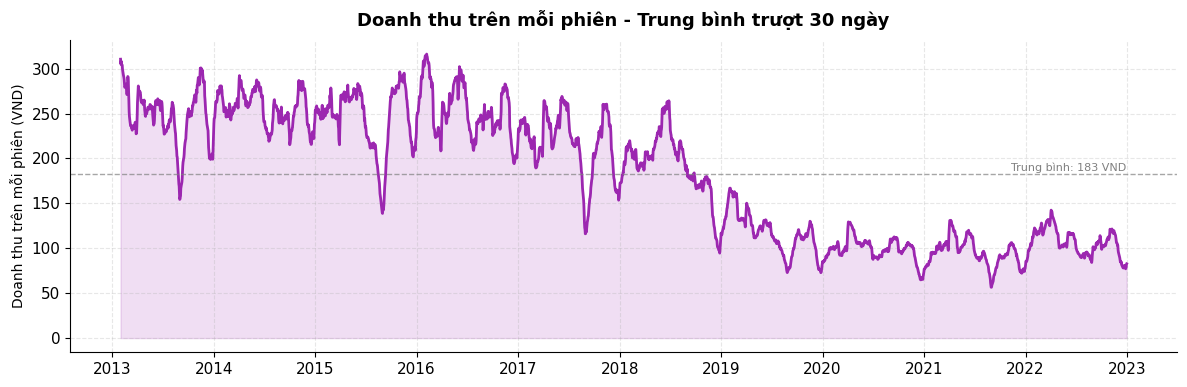

=== WEB TRAFFIC — KEY FINDINGS ===
Doanh thu trên mỗi phiên đạt đỉnh           : 316 VND (02/2016)
Doanh thu trên mỗi phiên kỳ gần nhất        : 83 VND
Lag tối ưu                                  : 1 ngày (r = 0.322)
Mức độ sụt giảm so với thời điểm đỉnh cao   : 73.8%
Doanh thu trung bình trên mỗi phiên truy cập: 183 VND
Kruskal-Wallis p                            : 0.5797
Các kênh suy giảm đồng đều

Tốc độ suy giảm hiệu quả theo kênh (VND/năm):
direct            -22.7
social_media      -22.2
email_campaign    -22.0
paid_search       -21.9
organic_search    -21.4
referral          -20.6

Xu hướng biến động của Giá trị đơn hàng trung bình (AOV slope): +928 VND/năm
→ AOV ổn định → vấn đề nằm ở conversion rate


In [7]:
# ── Chuẩn bị data ────────────────────────────────────────────
traffic_daily = (
    web_traffic.groupby('date')[['sessions']].sum()
               .reset_index().rename(columns={'date': 'Date'})
)
traffic_daily['Date'] = pd.to_datetime(traffic_daily['Date'])
sales['Date']         = pd.to_datetime(sales['Date'])

ts = (
    traffic_daily.merge(sales[['Date', 'Revenue']], on='Date', how='inner')
                 .sort_values('Date').reset_index(drop=True)
)

# Lag tối ưu
lags = range(0,15)

correlations = [
    ts['Revenue'].corr(
        ts['sessions'].shift(lag)
    )
    for lag in lags
]

best_lag = int(np.argmax(correlations))

ts['rev_per_sess']      = ts['Revenue'] / ts['sessions']
ts['rev_per_sess_roll'] = ts['rev_per_sess'].rolling(30).mean()
plot_df = ts.dropna(subset=['rev_per_sess_roll'])

# ── Key numbers ──────────────────────────────────────────────
peak_val  = plot_df['rev_per_sess_roll'].max()
peak_date = plot_df.loc[plot_df['rev_per_sess_roll'].idxmax(), 'Date']
last_val  = plot_df['rev_per_sess_roll'].iloc[-1]
avg_val   = plot_df['rev_per_sess_roll'].mean()
pct_drop  = (peak_val - last_val) / peak_val

# Kruskal-Wallis qua kênh
tr = (
    web_traffic.rename(columns={'date': 'Date'})
               .assign(Date=lambda x: pd.to_datetime(x['Date']))
               .merge(sales[['Date', 'Revenue']], on='Date', how='inner')
)
daily_total = tr.groupby('Date')['sessions'].transform('sum')
tr['rev_per_sess_channel'] = (
    tr['Revenue'] * (tr['sessions'] / daily_total) / tr['sessions']
)
groups  = [g['rev_per_sess_channel'].dropna().values
           for _, g in tr.groupby('traffic_source')]
_, p_kw = stats.kruskal(*groups)

# Decay rate theo kênh
src_trend = (
    tr.groupby([tr['Date'].dt.year, 'traffic_source'])['rev_per_sess_channel']
      .mean().reset_index()
)
src_trend.columns = ['year', 'source', 'rps']
decay = {}
for src, g in src_trend.groupby('source'):
    if len(g) > 2:
        decay[src] = np.polyfit(range(len(g)), g['rps'].values, 1)[0]
decay_df = pd.Series(decay).sort_values()

# ── Chart: Doanh thu trên mỗi phiên - Trung bình trượt 30 ngày ────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(plot_df['Date'], plot_df['rev_per_sess_roll'],
        color='#9C27B0', linewidth=2)
ax.fill_between(plot_df['Date'], plot_df['rev_per_sess_roll'],
                alpha=0.15, color='#9C27B0')
ax.axhline(avg_val, color='gray', linewidth=1, linestyle='--', alpha=0.7)
ax.text(plot_df['Date'].max(), avg_val + 3,
        f'Trung bình: {avg_val:.0f} VND', fontsize=8, color='gray', ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.set_ylabel('Doanh thu trên mỗi phiên (VND)')
ax.set_title('Doanh thu trên mỗi phiên - Trung bình trượt 30 ngày', pad=10)
plt.tight_layout()
plt.savefig(
    '/kaggle/working/TBT_Fig5_RevenuePerSession_Trend.png',  
    dpi=150,                       
    bbox_inches='tight',         
    facecolor='white',            
    format='png'                  
)
plt.show()

# ── Key findings ───────────────────────────────────────────
print("=== WEB TRAFFIC — KEY FINDINGS ===")
print(f"Doanh thu trên mỗi phiên đạt đỉnh           : {peak_val:.0f} VND ({peak_date.strftime('%m/%Y')})")
print(f"Doanh thu trên mỗi phiên kỳ gần nhất        : {last_val:.0f} VND")
print(f"Lag tối ưu                                  : {best_lag} ngày (r = {correlations[best_lag]:.3f})")
print(f"Mức độ sụt giảm so với thời điểm đỉnh cao   : {pct_drop:.1%}")
print(f"Doanh thu trung bình trên mỗi phiên truy cập: {avg_val:.0f} VND")
print(f"Kruskal-Wallis p                            : {p_kw:.4f}")
print(f"{'Các kênh suy giảm đồng đều' if p_kw > 0.05 else 'Khác biệt có ý nghĩa giữa các kênh'}")
print("\nTốc độ suy giảm hiệu quả theo kênh (VND/năm):")
print(decay_df.apply(lambda x: f"{x:+.1f}").to_string())

# AOV cross-check
orders['year'] = pd.to_datetime(orders['order_date']).dt.year
oi_rev = order_items.copy()
oi_rev['line_rev'] = oi_rev['unit_price'] * oi_rev['quantity'] - oi_rev['discount_amount']
aov_year = (
    oi_rev.groupby('order_id')['line_rev'].sum().reset_index()
          .merge(orders[['order_id', 'year']], on='order_id')
          .groupby('year')['line_rev'].mean()
)
aov_slope = np.polyfit(range(len(aov_year)), aov_year.values, 1)[0]
print(f"\nXu hướng biến động của Giá trị đơn hàng trung bình (AOV slope): {aov_slope:+.0f} VND/năm")
print("→ " + ("AOV giảm mạnh — nguyên nhân chính" if aov_slope < -100
               else "AOV ổn định → vấn đề nằm ở conversion rate"))

**Phân tích Địa lý (Region)**

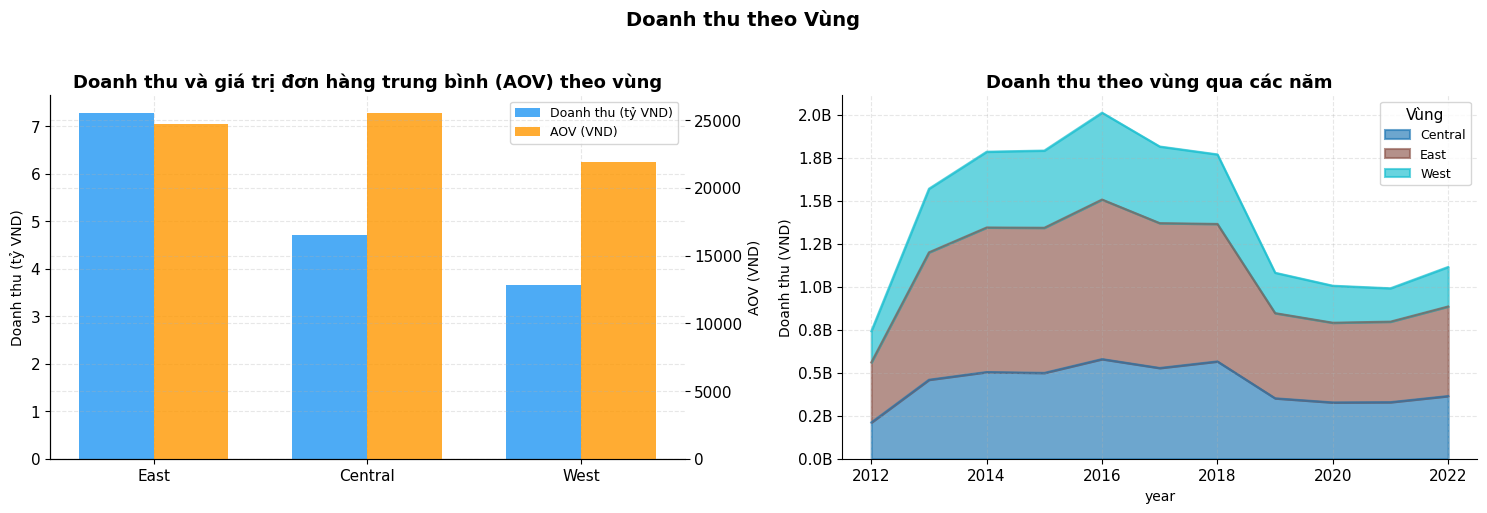

=== GEOGRAPHY — KEY FINDINGS ===
East       | Revenue: 7.29B | Orders: 294,612 | AOV: 24,748 VND
Central    | Revenue: 4.72B | Orders: 184,691 | AOV: 25,553 VND
West       | Revenue: 3.67B | Orders: 167,642 | AOV: 21,893 VND

Khu vực có AOV cao nhất: Central (25,553 VND)


In [8]:
# ── Chuẩn bị data ────────────────────────────────────────────
oi_rev = order_items.copy()
oi_rev['line_revenue'] = (
    oi_rev['unit_price'] * oi_rev['quantity'] - oi_rev['discount_amount']
)
order_rev = oi_rev.groupby('order_id')['line_revenue'].sum().reset_index()
order_rev_geo = order_rev.merge(
    orders_geo[['order_id', 'region', 'order_date']], on='order_id', how='left'
)
order_rev_geo['year'] = pd.to_datetime(order_rev_geo['order_date']).dt.year

region_summary = (
    order_rev_geo.groupby('region')
                 .agg(total_revenue=('line_revenue', 'sum'),
                      order_count=('order_id', 'count'),
                      aov=('line_revenue', 'mean'))
                 .sort_values('total_revenue', ascending=False)
                 .reset_index()
)
region_year  = order_rev_geo.groupby(['region', 'year'])['line_revenue'].sum().reset_index()
region_pivot = region_year.pivot(index='year', columns='region', values='line_revenue')

# ── Chart: stacked area + bar summary ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar: revenue + AOV
x     = np.arange(len(region_summary))
width = 0.35
axes[0].bar(x - width/2, region_summary['total_revenue'] / 1e9,
            width, color='#2196F3', alpha=0.8, label='Doanh thu (tỷ VND)')
ax2 = axes[0].twinx()
ax2.bar(x + width/2, region_summary['aov'],
        width, color='#FF9800', alpha=0.8, label='AOV (VND)')
axes[0].set_xticks(x); axes[0].set_xticklabels(region_summary['region'])
axes[0].set_ylabel('Doanh thu (tỷ VND)'); ax2.set_ylabel('AOV (VND)')
axes[0].set_title('Doanh thu và giá trị đơn hàng trung bình (AOV) theo vùng')
lines1, l1 = axes[0].get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, l1 + l2, fontsize=9)

# Stacked area
region_pivot.plot(kind='area', ax=axes[1], alpha=0.65,
                  colormap='tab10', linewidth=1.5)
axes[1].set_title('Doanh thu theo vùng qua các năm')
axes[1].set_ylabel('Doanh thu (VND)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
axes[1].legend(title='Vùng', fontsize=9)

plt.suptitle('Doanh thu theo Vùng',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(
    '/kaggle/working/TBT_Fig6_Region_Rating_ReturnRate.png',  
    dpi=150,                       
    bbox_inches='tight',         
    facecolor='white',            
    format='png'                  
)
plt.show()

# ── Print findings ───────────────────────────────────────────
print("=== GEOGRAPHY — KEY FINDINGS ===")
for _, r in region_summary.iterrows():
    print(f"{r['region']:10s} | Revenue: {r['total_revenue']/1e9:.2f}B | "
          f"Orders: {r['order_count']:,} | AOV: {r['aov']:,.0f} VND")
aov_top = region_summary.sort_values('aov', ascending=False).iloc[0]
print(f"\nKhu vực có AOV cao nhất: {aov_top['region']} ({aov_top['aov']:,.0f} VND)")

**Rating × Return Rate**

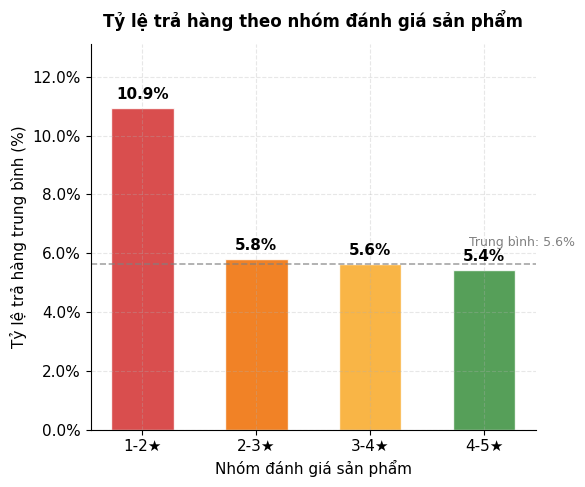

Tương quan r           : -0.099
Tỷ lệ trả hàng 1-2★   : 10.9%
Tỷ lệ trả hàng 4-5★   : 5.4%
Chênh lệch             : 5.5%
Số SP mỗi nhóm:
rating_group  count
        1-2★     16
        2-3★     48
        3-4★    892
        4-5★    456


In [9]:
# ── Chuẩn bị data ────────────────────────────────────────────
avg_rating = (
    reviews.groupby('product_id')['rating'].mean().reset_index()
           .rename(columns={'rating': 'avg_rating'})
)
avg_rating['rating_group'] = pd.cut(
    avg_rating['avg_rating'],
    bins=[0, 2, 3, 4, 5],
    labels=['1-2★', '2-3★', '3-4★', '4-5★']
)

ret_prod2 = (
    returns.groupby('product_id')['return_id'].count().reset_index()
           .rename(columns={'return_id': 'ret_count'})
)
oi_prod2 = (
    order_items.groupby('product_id')['order_id'].count().reset_index()
               .rename(columns={'order_id': 'oi_count'})
)

prod_rate = oi_prod2.merge(ret_prod2, on='product_id', how='left')
prod_rate['ret_count']   = prod_rate['ret_count'].fillna(0)
prod_rate['return_rate'] = prod_rate['ret_count'] / prod_rate['oi_count']

prod_analysis = (
    prod_rate.merge(avg_rating, on='product_id', how='inner')
             .merge(products[['product_id', 'category']], on='product_id', how='left')
)
rate_by_group = (
    prod_analysis.groupby('rating_group', observed=True)
                 .agg(avg_return_rate=('return_rate', 'mean'),
                      count=('product_id', 'count'))
                 .reset_index()
)

# ── Key numbers ──────────────────────────────────────────────
corr     = prod_analysis['avg_rating'].corr(prod_analysis['return_rate'])
low_ret  = rate_by_group[rate_by_group['rating_group'] == '1-2★']['avg_return_rate'].values[0]
high_ret = rate_by_group[rate_by_group['rating_group'] == '4-5★']['avg_return_rate'].values[0]
gap      = low_ret - high_ret

# ── Chart: Bar chart return rate theo nhóm rating ────────────
fig, ax = plt.subplots(figsize=(6, 5))

bar_colors = ['#d32f2f', '#ef6c00', '#f9a825', '#388e3c']
bars = ax.bar(
    rate_by_group['rating_group'],
    rate_by_group['avg_return_rate'] * 100,
    color=bar_colors, alpha=0.85, edgecolor='white', width=0.55
)

# Label số liệu trên mỗi bar
for bar, val in zip(bars, rate_by_group['avg_return_rate']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{val:.1%}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

# Đường trung bình toàn danh mục
avg_all = prod_analysis['return_rate'].mean()
ax.axhline(avg_all * 100, color='gray', linewidth=1.2,
           linestyle='--', alpha=0.7)
ax.text(
    len(rate_by_group) - 0.2, avg_all * 100 + 0.6,
    f'Trung bình: {avg_all:.1%}',
    fontsize=9, color='gray', ha='right'
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Nhóm đánh giá sản phẩm', fontsize=11)
ax.set_ylabel('Tỷ lệ trả hàng trung bình (%)', fontsize=11)
ax.set_title(
    'Tỷ lệ trả hàng theo nhóm đánh giá sản phẩm',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_ylim(0, rate_by_group['avg_return_rate'].max() * 100 * 1.2)

plt.tight_layout()
plt.savefig(
    '/kaggle/working/TBT_Fig7_Rating_ReturnRate_Scatter.png',  
    dpi=150,                       
    bbox_inches='tight',         
    facecolor='white',            
    format='png'                  
)
plt.show()

# ── Print findings ───────────────────────────────────────────
print(f"Tương quan r           : {corr:.3f}")
print(f"Tỷ lệ trả hàng 1-2★   : {low_ret:.1%}")
print(f"Tỷ lệ trả hàng 4-5★   : {high_ret:.1%}")
print(f"Chênh lệch             : {gap:.1%}")
print(f"Số SP mỗi nhóm:")
print(rate_by_group[['rating_group', 'count']].to_string(index=False))

In [10]:
import zipfile
import os

# Đảm bảo tất cả chart đã được lưu vào /kaggle/working/
charts = [
    '/kaggle/working/TBT_Fig3_ReturnRate_SizeCategory.png',
    '/kaggle/working/TBT_Fig4_Stockout_RevenueLost.png',
    '/kaggle/working/TBT_Fig5_RevenuePerSession_Trend.png',
    '/kaggle/working/TBT_Fig6_Region_Rating_ReturnRate.png',
    '/kaggle/working/TBT_Fig7_Rating_ReturnRate_Scatter.png',
]

# Tạo file zip
with zipfile.ZipFile('/kaggle/working/TBT_charts.zip', 'w') as zipf:
    for chart in charts:
        if os.path.exists(chart):
            zipf.write(chart, os.path.basename(chart))
            print(f"Đã thêm: {os.path.basename(chart)}")
        else:
            print(f"Không tìm thấy: {chart}")

print("\nXong — vào tab Output bên phải để download TBT_charts.zip")

Đã thêm: TBT_Fig3_ReturnRate_SizeCategory.png
Đã thêm: TBT_Fig4_Stockout_RevenueLost.png
Đã thêm: TBT_Fig5_RevenuePerSession_Trend.png
Đã thêm: TBT_Fig6_Region_Rating_ReturnRate.png
Đã thêm: TBT_Fig7_Rating_ReturnRate_Scatter.png

Xong — vào tab Output bên phải để download TBT_charts.zip
